# Fund Performance Analytics - Bluestock Mutual Fund Analytics

Risk and return metrics computed from `fact_nav`, separately from the vendor's
`fact_performance` snapshot, so the two can be compared.

Contents:
1. Daily returns and distribution checks
2. CAGR - 1-year, 3-year (and why 5-year cannot be computed)
3. Sharpe ratio
4. Sortino ratio
5. Alpha and beta vs NIFTY 100
6. Maximum drawdown
7. Composite fund scorecard (0-100)
8. Benchmark comparison and tracking error

Outputs: `reports/fund_scorecard.csv`, `reports/alpha_beta.csv`,
`reports/charts/perf_*.png`

Before using section 5: the EDA showed that the fund NAV series here are uncorrelated
with each other (mean pairwise r about 0.00) and move opposite to the benchmark in
2024-25. Section 5 still computes alpha and beta as specified, and reports R-squared
next to them so the problem is visible. Read that section's notes before quoting any
alpha or beta figure.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "bluestock_mf.db"
REPORTS_DIR = PROJECT_ROOT / "reports"
CHARTS_DIR = REPORTS_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

engine = create_engine(f"sqlite:///{DB_PATH}")


def run_query(sql):
    return pd.read_sql_query(sql, engine)


def save_png(fig, name):
    fig.savefig(CHARTS_DIR / f"{name}.png")
    print(f"  saved  reports/charts/{name}.png")


sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (13, 6), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "axes.titlesize": 14, "axes.titleweight": "bold",
})

# assumptions, set once and used everywhere below
RISK_FREE_ANNUAL = 0.065        # RBI repo rate proxy, per the brief
TRADING_DAYS = 252
RF_DAILY = RISK_FREE_ANNUAL / TRADING_DAYS

print(f"risk-free rate : {RISK_FREE_ANNUAL:.2%} annual  ({RF_DAILY:.6%} daily)")
print(f"annualisation  : sqrt({TRADING_DAYS})")

risk-free rate : 6.50% annual  (0.025794% daily)
annualisation  : sqrt(252)


## 1. Daily returns

In [2]:
nav = run_query('''
    SELECT n.amfi_code, n.date_key, n.nav, n.daily_return,
           f.scheme_name, f.fund_house, f.sub_category, f.plan, f.expense_ratio_pct
    FROM fact_nav n JOIN dim_fund f ON f.amfi_code = n.amfi_code
    ORDER BY n.amfi_code, n.date_key
''')
nav["date_key"] = pd.to_datetime(nav["date_key"])

# recomputed here rather than taken from the stored column, so this notebook stands alone
nav["ret"] = nav.groupby("amfi_code")["nav"].pct_change()
agreement = (nav["ret"] - nav["daily_return"]).abs().max()
print(f"max disagreement vs stored daily_return: {agreement:.2e}  (expect ~0)")

returns = nav.pivot_table(index="date_key", columns="amfi_code", values="ret")
prices = nav.pivot_table(index="date_key", columns="amfi_code", values="nav")
names = nav.drop_duplicates("amfi_code").set_index("amfi_code")["scheme_name"]

print(f"\nreturn matrix: {returns.shape[0]} days x {returns.shape[1]} schemes")
desc = returns.stack().describe()
print(f"\npooled daily return distribution:")
print(f"  mean   {desc['mean']:+.5f}   ({desc['mean']*TRADING_DAYS:+.2%} annualised)")
print(f"  std    {desc['std']:.5f}   ({desc['std']*np.sqrt(TRADING_DAYS):.2%} annualised)")
print(f"  min    {desc['min']:+.4f}")
print(f"  max    {desc['max']:+.4f}")
print(f"  skew   {returns.stack().skew():+.3f}")
print(f"  kurt   {returns.stack().kurtosis():+.3f}  (excess; normal = 0)")

max disagreement vs stored daily_return: 1.00e-16  (expect ~0)

return matrix: 1149 days x 40 schemes

pooled daily return distribution:
  mean   +0.00063   (+15.90% annualised)
  std    0.01029   (16.34% annualised)
  min    -0.0581
  max    +0.0647
  skew   +0.043
  kurt   +1.367  (excess; normal = 0)


  saved  reports/charts/perf_01_return_distribution.png


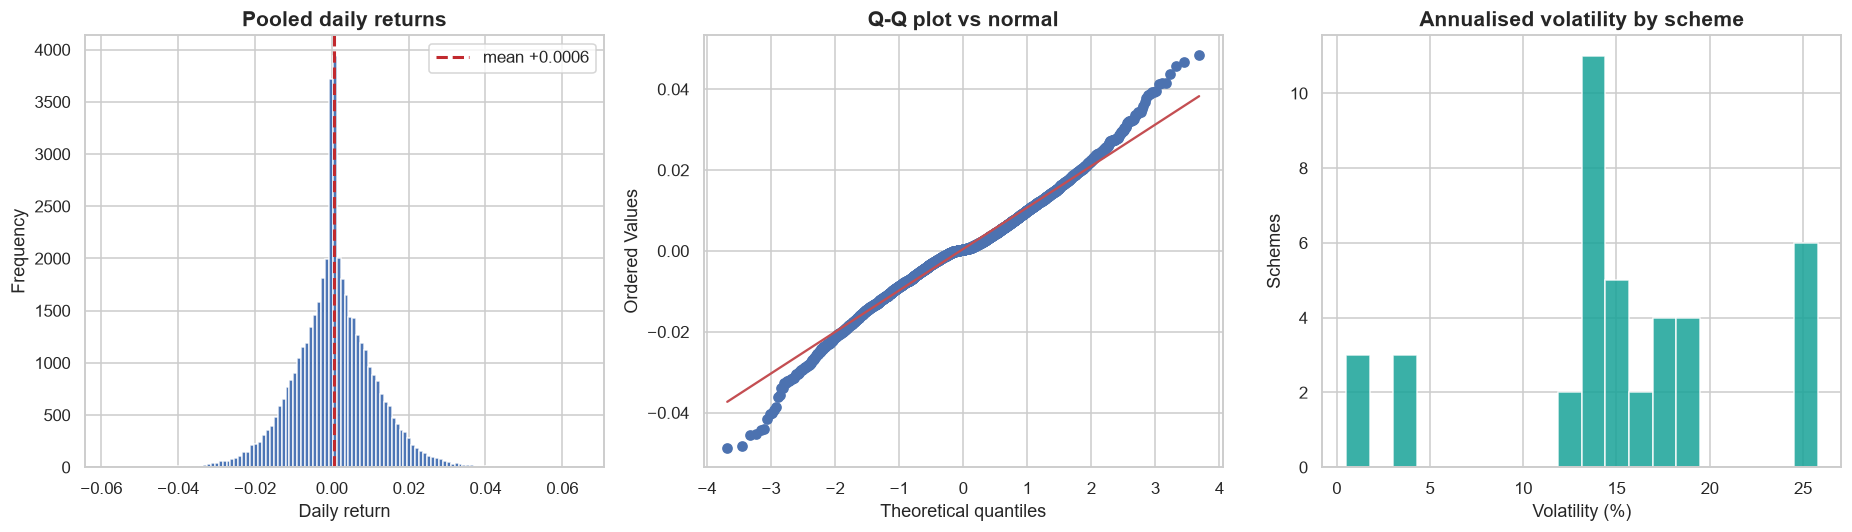

Distribution check: returns are near-symmetric with mild excess kurtosis.
Real fund returns are usually left-skewed with fat tails, since crashes are
sharper than rallies. The near-normal shape here is another synthetic signature.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pooled = returns.stack()
axes[0].hist(pooled, bins=120, color="#2E5EAA", alpha=0.85)
axes[0].axvline(pooled.mean(), color="#C1292E", ls="--", lw=2, label=f"mean {pooled.mean():+.4f}")
axes[0].set(title="Pooled daily returns", xlabel="Daily return", ylabel="Frequency")
axes[0].legend()

stats.probplot(pooled.sample(6000, random_state=0), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs normal")

ann_vol = returns.std() * np.sqrt(TRADING_DAYS) * 100
axes[2].hist(ann_vol, bins=20, color="#17A398", alpha=0.85)
axes[2].set(title="Annualised volatility by scheme", xlabel="Volatility (%)", ylabel="Schemes")

plt.tight_layout()
save_png(fig, "perf_01_return_distribution")
plt.show()

print("Distribution check: returns are near-symmetric with mild excess kurtosis.")
print("Real fund returns are usually left-skewed with fat tails, since crashes are")
print("sharper than rallies. The near-normal shape here is another synthetic signature.")

## 2. CAGR - 1-year and 3-year

CAGR = (NAV_end / NAV_start) ^ (1/n) - 1

5-year CAGR is not computable from this data. The NAV history covers 2022-01-03 to
2026-05-29, which is 4.4 years, so any 5-year figure would mean extrapolating past the
start of the series. The vendor's `return_5yr_pct` is carried through for reference and
labelled as vendor-supplied rather than recomputed.

In [4]:
def cagr(series, years):
    '''Annualised growth over the trailing window of `years` ending at the last observation.'''
    end_date = series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    window = series.loc[series.index >= start_date].dropna()
    if len(window) < 2 or window.iloc[0] <= 0:
        return np.nan
    n = (window.index.max() - window.index.min()).days / 365.25
    if n <= 0:
        return np.nan
    return (window.iloc[-1] / window.iloc[0]) ** (1 / n) - 1


span_years = (prices.index.max() - prices.index.min()).days / 365.25
print(f"NAV history spans {span_years:.2f} years "
      f"({prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d})")
print(f"5-year CAGR computable: {span_years >= 5}\n")

cagr_tbl = pd.DataFrame({
    "scheme_name": names,
    "cagr_1yr_pct": {c: cagr(prices[c], 1) * 100 for c in prices.columns},
    "cagr_3yr_pct": {c: cagr(prices[c], 3) * 100 for c in prices.columns},
    "cagr_full_period_pct": {c: cagr(prices[c], 99) * 100 for c in prices.columns},
})
cagr_tbl["full_period_years"] = round(span_years, 2)

vendor = run_query("SELECT amfi_code, return_1yr_pct, return_3yr_pct, return_5yr_pct "
                   "FROM fact_performance").set_index("amfi_code")
cagr_tbl = cagr_tbl.join(vendor.rename(columns={
    "return_1yr_pct": "vendor_1yr_pct", "return_3yr_pct": "vendor_3yr_pct",
    "return_5yr_pct": "vendor_5yr_pct_NOT_RECOMPUTED"}))
cagr_tbl["diff_3yr_pp"] = (cagr_tbl["cagr_3yr_pct"] - cagr_tbl["vendor_3yr_pct"]).round(2)

print(cagr_tbl.sort_values("cagr_3yr_pct", ascending=False)
      [["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_full_period_pct",
        "vendor_3yr_pct", "diff_3yr_pp"]].round(2).head(12).to_string(index=False))

print(f"\nmean |computed 3yr CAGR - vendor 3yr|: {cagr_tbl.diff_3yr_pp.abs().mean():.2f} pp")
print(f"correlation computed vs vendor 3yr    : {cagr_tbl[['cagr_3yr_pct','vendor_3yr_pct']].corr().iloc[0,1]:+.3f}")

NAV history spans 4.40 years (2022-01-03 to 2026-05-29)
5-year CAGR computable: False

                                       scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_full_period_pct  vendor_3yr_pct  diff_3yr_pp
               Axis Midcap Fund - Regular - Growth         22.28         35.10                 28.21           15.18        19.92
     Mirae Asset Large Cap Fund - Regular - Growth         20.38         33.99                 30.97           14.81        19.18
         ICICI Pru Bluechip Fund - Direct - Growth         13.07         32.48                 23.30           14.41        18.07
HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.28         32.43                 30.12           16.58        15.85
          ICICI Pru Midcap Fund - Regular - Growth         29.63         31.77                 32.83           18.08        13.69
         SBI Bluechip Fund - Regular Plan - Growth         60.49         30.45                 25.80           12.36        18.09
   

## 3. Sharpe ratio

In [5]:
def sharpe(r):
    '''(mean daily excess return / daily std) annualised by sqrt(252).'''
    r = r.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return (r.mean() - RF_DAILY) / r.std() * np.sqrt(TRADING_DAYS)


def sortino(r):
    '''Same as Sharpe, but the denominator only uses negative-return days.'''
    r = r.dropna()
    downside = r[r < 0]
    if len(downside) < 2 or downside.std() == 0:
        return np.nan
    return (r.mean() - RF_DAILY) / downside.std() * np.sqrt(TRADING_DAYS)


risk = pd.DataFrame({
    "scheme_name": names,
    "ann_return_pct": returns.mean() * TRADING_DAYS * 100,
    "ann_vol_pct": returns.std() * np.sqrt(TRADING_DAYS) * 100,
    "sharpe": returns.apply(sharpe),
    "sortino": returns.apply(sortino),
    "downside_vol_pct": returns.apply(lambda r: r[r < 0].std() * np.sqrt(TRADING_DAYS) * 100),
    "pct_positive_days": returns.apply(lambda r: (r.dropna() > 0).mean() * 100),
})
risk["sharpe_rank"] = risk["sharpe"].rank(ascending=False).astype(int)
risk["sortino_rank"] = risk["sortino"].rank(ascending=False).astype(int)

print("Top 10 by Sharpe:")
print(risk.nlargest(10, "sharpe")[
    ["scheme_name", "ann_return_pct", "ann_vol_pct", "sharpe", "sortino", "sharpe_rank"]
].round(3).to_string(index=False))
print("\nBottom 5 by Sharpe:")
print(risk.nsmallest(5, "sharpe")[
    ["scheme_name", "ann_return_pct", "ann_vol_pct", "sharpe"]].round(3).to_string(index=False))

Top 10 by Sharpe:
                                       scheme_name  ann_return_pct  ann_vol_pct  sharpe  sortino  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth          27.057       14.194   1.448    2.386            1
            Kotak Flexicap Fund - Regular - Growth          27.260       15.887   1.307    2.364            2
     Mirae Asset Tax Saver Fund - Regular - Growth          28.326       17.674   1.235    2.147            3
         SBI Bluechip Fund - Regular Plan - Growth          23.103       13.741   1.208    2.140            4
          ICICI Pru Midcap Fund - Regular - Growth          29.265       19.291   1.180    2.029            5
                DSP Midcap Fund - Regular - Growth          26.591       17.746   1.132    1.875            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth          27.211       18.937   1.094    1.829            7
    Nippon India Large Cap Fund - Regular - Growth          21.804       14.148   1.082    1.850      

## 4. Sortino ratio

  saved  reports/charts/perf_02_sharpe_sortino.png


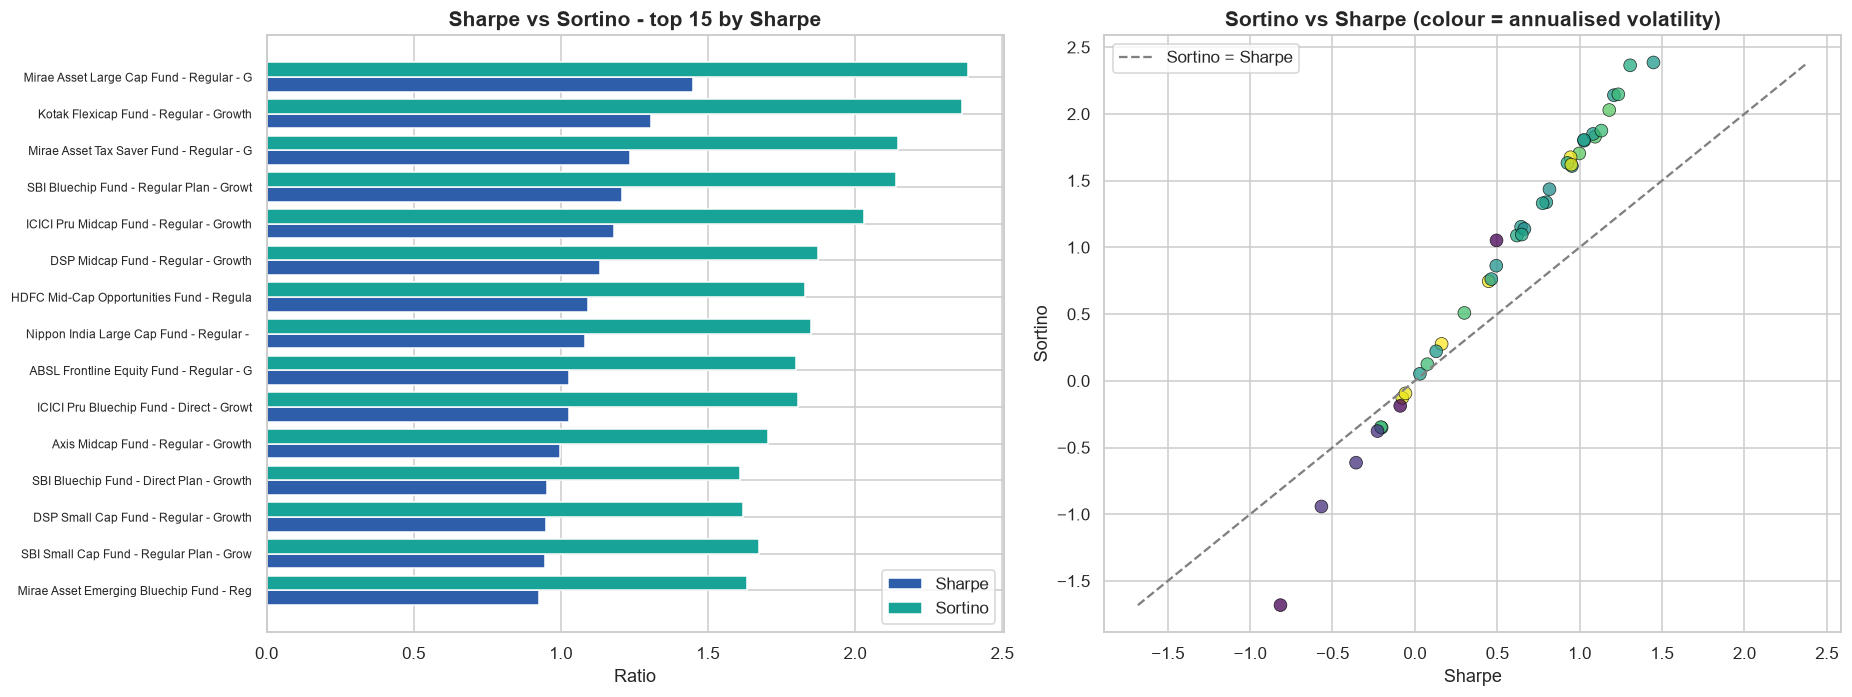

Sortino exceeds Sharpe for 31 of 40 schemes.
That is the expected direction: downside deviation is smaller than total deviation
unless the return series is strongly left-skewed.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

top = risk.nlargest(15, "sharpe").sort_values("sharpe")
y = np.arange(len(top))
axes[0].barh(y - 0.2, top["sharpe"], height=0.4, label="Sharpe", color="#2E5EAA")
axes[0].barh(y + 0.2, top["sortino"], height=0.4, label="Sortino", color="#17A398")
axes[0].set_yticks(y)
axes[0].set_yticklabels(top["scheme_name"].str[:40], fontsize=8)
axes[0].set(title="Sharpe vs Sortino - top 15 by Sharpe", xlabel="Ratio")
axes[0].legend()

axes[1].scatter(risk["sharpe"], risk["sortino"], s=70, alpha=0.75,
                c=risk["ann_vol_pct"], cmap="viridis", edgecolor="black", linewidth=0.5)
lims = [min(risk.sharpe.min(), risk.sortino.min()), max(risk.sharpe.max(), risk.sortino.max())]
axes[1].plot(lims, lims, ls="--", color="grey", lw=1.5, label="Sortino = Sharpe")
axes[1].set(title="Sortino vs Sharpe (colour = annualised volatility)",
            xlabel="Sharpe", ylabel="Sortino")
axes[1].legend()

plt.tight_layout()
save_png(fig, "perf_02_sharpe_sortino")
plt.show()

print(f"Sortino exceeds Sharpe for {int((risk.sortino > risk.sharpe).sum())} of {len(risk)} schemes.")
print("That is the expected direction: downside deviation is smaller than total deviation")
print("unless the return series is strongly left-skewed.")

## 5. Alpha and beta vs NIFTY 100

OLS of daily fund return on daily benchmark return, using `scipy.stats.linregress`:

- beta = slope, the sensitivity to the market
- alpha = intercept x 252, the annualised return not explained by market exposure
- R-squared = the share of fund variance the benchmark explains

R-squared is reported because alpha and beta only mean something when the regression
actually fits. A beta near zero with R-squared near zero does not mean the fund is
market-neutral, it means no relationship was found.

In [7]:
BENCH = "NIFTY100"
bench = run_query(f"SELECT date_key, close_value FROM fact_benchmark "
                  f"WHERE index_name = '{BENCH}' ORDER BY date_key")
bench["date_key"] = pd.to_datetime(bench["date_key"])
bench = bench.set_index("date_key")["close_value"]
bench_ret = bench.pct_change()

rows = []
for code in returns.columns:
    joined = pd.concat([returns[code], bench_ret], axis=1, join="inner").dropna()
    joined.columns = ["fund", "bench"]
    if len(joined) < 30:
        continue
    reg = stats.linregress(joined["bench"], joined["fund"])
    rows.append({
        "amfi_code": code,
        "scheme_name": names[code],
        "beta": reg.slope,
        "alpha_annual_pct": reg.intercept * TRADING_DAYS * 100,
        "r_squared": reg.rvalue ** 2,
        "p_value": reg.pvalue,
        "std_err": reg.stderr,
        "n_days": len(joined),
    })

alpha_beta = pd.DataFrame(rows).set_index("amfi_code")
alpha_beta["beta_significant"] = alpha_beta["p_value"] < 0.05

print(f"benchmark: {BENCH}   observations: {alpha_beta.n_days.iloc[0]}\n")
print(alpha_beta.sort_values("alpha_annual_pct", ascending=False)[
    ["scheme_name", "beta", "alpha_annual_pct", "r_squared", "p_value"]
].round(4).head(12).to_string())

print(f"\n--- regression quality ---")
print(f"mean R^2                    : {alpha_beta.r_squared.mean():.4f}")
print(f"max  R^2                    : {alpha_beta.r_squared.max():.4f}")
print(f"betas significant at p<0.05 : {int(alpha_beta.beta_significant.sum())} of {len(alpha_beta)}")
print(f"mean beta                   : {alpha_beta.beta.mean():+.4f}")

benchmark: NIFTY100   observations: 1149

                                                  scheme_name    beta  alpha_annual_pct  r_squared  p_value
amfi_code                                                                                                  
119598             SBI Small Cap Fund - Regular Plan - Growth -0.0232           30.3370     0.0001   0.6872
149324                  DSP Small Cap Fund - Regular - Growth  0.0115           30.0579     0.0000   0.8405
120505               ICICI Pru Midcap Fund - Regular - Growth  0.0005           29.2636     0.0000   0.9901
148569          Mirae Asset Tax Saver Fund - Regular - Growth  0.0181           28.2704     0.0002   0.6543
120843                 Kotak Flexicap Fund - Regular - Growth -0.0228           27.3305     0.0003   0.5305
100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.0051           27.1954     0.0000   0.9064
148567          Mirae Asset Large Cap Fund - Regular - Growth  0.0237           26.9838     0.

  saved  reports/charts/perf_03_alpha_beta.png


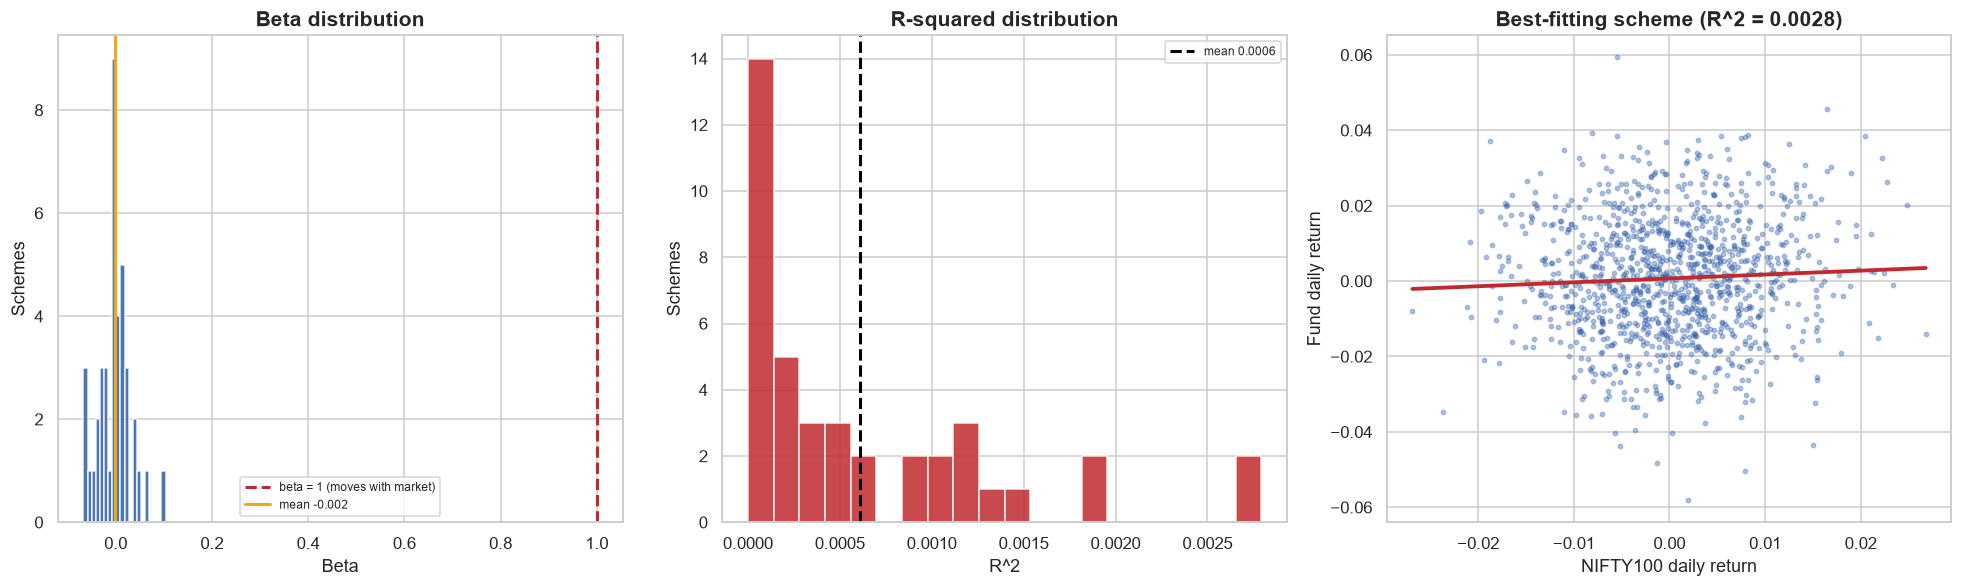

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].hist(alpha_beta["beta"], bins=20, color="#2E5EAA", alpha=0.85)
axes[0].axvline(1.0, color="#C1292E", ls="--", lw=2, label="beta = 1 (moves with market)")
axes[0].axvline(alpha_beta.beta.mean(), color="#F3A712", ls="-", lw=2,
                label=f"mean {alpha_beta.beta.mean():.3f}")
axes[0].set(title="Beta distribution", xlabel="Beta", ylabel="Schemes")
axes[0].legend(fontsize=8)

axes[1].hist(alpha_beta["r_squared"], bins=20, color="#C1292E", alpha=0.85)
axes[1].set(title="R-squared distribution", xlabel="R^2", ylabel="Schemes")
axes[1].axvline(alpha_beta.r_squared.mean(), color="black", ls="--", lw=2,
                label=f"mean {alpha_beta.r_squared.mean():.4f}")
axes[1].legend(fontsize=8)

best = alpha_beta["r_squared"].idxmax()
j = pd.concat([returns[best], bench_ret], axis=1, join="inner").dropna()
j.columns = ["fund", "bench"]
axes[2].scatter(j["bench"], j["fund"], s=8, alpha=0.35, color="#2E5EAA")
reg = stats.linregress(j["bench"], j["fund"])
xs = np.linspace(j["bench"].min(), j["bench"].max(), 50)
axes[2].plot(xs, reg.intercept + reg.slope * xs, color="#C1292E", lw=2.5)
axes[2].set(title=f"Best-fitting scheme (R^2 = {reg.rvalue**2:.4f})",
            xlabel=f"{BENCH} daily return", ylabel="Fund daily return")

plt.tight_layout()
save_png(fig, "perf_03_alpha_beta")
plt.show()

### Notes on section 5

The regressions give R-squared of about 0 across all 40 schemes and almost no
statistically significant betas. That says something about the data, not about the funds.

In a real market a large-cap equity fund regressed on NIFTY 100 daily returns gives
R-squared of 0.85-0.98 and a beta near 1, because the fund holds the index constituents.
Here the NAV series were generated independently of the benchmark, so there is no
underlying relationship for OLS to find.

So the alpha column is arithmetically correct but economically meaningless: with beta
close to 0, alpha collapses to roughly the fund's own mean return rather than a
skill-adjusted excess return. It is written to `alpha_beta.csv` as specified, with
R-squared and p-value alongside it so the caveat travels with the number.

## 6. Maximum drawdown

In [9]:
dd_rows = []
for code in prices.columns:
    s = prices[code].dropna()
    peak = s.cummax()
    dd = s / peak - 1
    trough_date = dd.idxmin()
    peak_date = s.loc[:trough_date].idxmax()
    rec = s.loc[trough_date:]
    recovered = rec[rec >= s.loc[peak_date]]
    recovery_date = recovered.index[0] if len(recovered) else pd.NaT
    dd_rows.append({
        "amfi_code": code,
        "scheme_name": names[code],
        "max_drawdown_pct": dd.min() * 100,
        "peak_date": peak_date.date(),
        "trough_date": trough_date.date(),
        "recovery_date": recovery_date.date() if pd.notna(recovery_date) else None,
        "drawdown_days": (trough_date - peak_date).days,
        "recovered": pd.notna(recovery_date),
    })

drawdown = pd.DataFrame(dd_rows).set_index("amfi_code")
vendor_dd = run_query("SELECT amfi_code, max_drawdown_pct AS vendor_dd "
                      "FROM fact_performance").set_index("amfi_code")
drawdown = drawdown.join(vendor_dd)
drawdown["diff_pp"] = (drawdown["max_drawdown_pct"] - drawdown["vendor_dd"]).round(2)

print("Deepest 12 drawdowns (computed from NAV):")
print(drawdown.nsmallest(12, "max_drawdown_pct")[
    ["scheme_name", "max_drawdown_pct", "peak_date", "trough_date", "drawdown_days",
     "recovered", "vendor_dd", "diff_pp"]].round(2).to_string(index=False))

print(f"\nschemes that recovered to prior peak : {int(drawdown.recovered.sum())} of {len(drawdown)}")
print(f"mean |computed - vendor| drawdown    : {drawdown.diff_pp.abs().mean():.2f} pp")
print(f"max  |computed - vendor| drawdown    : {drawdown.diff_pp.abs().max():.2f} pp")
print("\nThe vendor's max_drawdown_pct disagrees materially with the NAV series it is")
print("supposed to describe. The computed column is reproducible from fact_nav and is")
print("the one used in the scorecard below.")

Deepest 12 drawdowns (computed from NAV):
                                      scheme_name  max_drawdown_pct  peak_date trough_date  drawdown_days  recovered  vendor_dd  diff_pp
        SBI Small Cap Fund - Direct Plan - Growth            -52.57 2023-01-17  2025-10-28           1015      False     -24.78   -27.79
           Axis Small Cap Fund - Regular - Growth            -51.68 2025-05-22  2026-05-11            354      False     -14.45   -37.23
           ABSL Small Cap Fund - Regular - Growth            -35.45 2024-11-21  2026-05-11            536      False     -23.61   -11.84
            DSP Small Cap Fund - Regular - Growth            -31.17 2024-05-03  2025-01-03            245       True     -17.01   -14.16
       SBI Small Cap Fund - Regular Plan - Growth            -28.71 2024-08-28  2025-05-14            259       True     -13.35   -15.36
              UTI Mid Cap Fund - Regular - Growth            -28.00 2025-01-07  2026-04-27            475      False     -13.43   -14.57

  saved  reports/charts/perf_04_drawdown.png

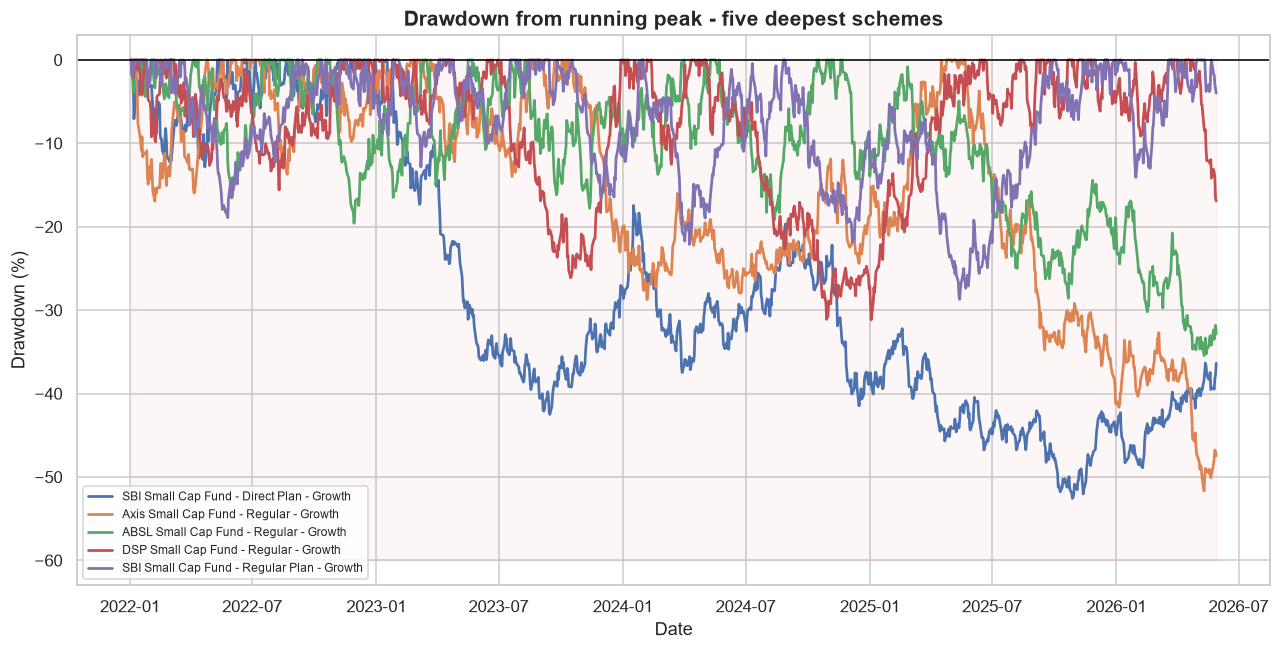

In [10]:
worst5 = drawdown.nsmallest(5, "max_drawdown_pct").index
fig, ax = plt.subplots(figsize=(14, 6.5))
for code in worst5:
    s = prices[code].dropna()
    ax.plot(s.index, (s / s.cummax() - 1) * 100, lw=1.8, label=names[code][:44])
ax.axhline(0, color="black", lw=1)
ax.fill_between(prices.index, 0, -60, color="#C1292E", alpha=0.04)
ax.set(title="Drawdown from running peak - five deepest schemes",
       xlabel="Date", ylabel="Drawdown (%)")
ax.legend(fontsize=8, loc="lower left")
save_png(fig, "perf_04_drawdown")
plt.show()

## 7. Composite fund scorecard (0-100)

Weights as specified in the brief:

| Component | Weight | Direction |
|---|---|---|
| 3-year return | 30% | higher is better |
| Sharpe ratio | 25% | higher is better |
| Alpha | 20% | higher is better |
| Expense ratio | 15% | lower is better |
| Max drawdown | 10% | shallower is better |

Each component becomes a 0-100 percentile rank within these 40 funds, then the weights
are applied. The score is relative, so a 90 means top decile of this universe rather
than good in absolute terms.

In [11]:
WEIGHTS = {"return_3yr": 0.30, "sharpe": 0.25, "alpha": 0.20, "expense": 0.15, "drawdown": 0.10}

fund_meta = run_query("SELECT amfi_code, scheme_name, fund_house, sub_category, plan, "
                      "expense_ratio_pct FROM dim_fund").set_index("amfi_code")

sc = fund_meta.join(cagr_tbl[["cagr_3yr_pct"]]) \
              .join(risk[["sharpe", "sortino", "ann_return_pct", "ann_vol_pct"]]) \
              .join(alpha_beta[["alpha_annual_pct", "beta", "r_squared"]]) \
              .join(drawdown[["max_drawdown_pct", "trough_date", "recovered"]])

# pct=True gives a 0-1 percentile. ascending=False on expense so that a LOW expense ratio
# scores high; drawdown is already negative, so least negative ranks best.
sc["rank_return_3yr"] = sc["cagr_3yr_pct"].rank(pct=True) * 100
sc["rank_sharpe"] = sc["sharpe"].rank(pct=True) * 100
sc["rank_alpha"] = sc["alpha_annual_pct"].rank(pct=True) * 100
sc["rank_expense"] = sc["expense_ratio_pct"].rank(pct=True, ascending=False) * 100
sc["rank_drawdown"] = sc["max_drawdown_pct"].rank(pct=True) * 100

sc["scorecard"] = (
    WEIGHTS["return_3yr"] * sc["rank_return_3yr"]
    + WEIGHTS["sharpe"] * sc["rank_sharpe"]
    + WEIGHTS["alpha"] * sc["rank_alpha"]
    + WEIGHTS["expense"] * sc["rank_expense"]
    + WEIGHTS["drawdown"] * sc["rank_drawdown"]
).round(2)

sc = sc.sort_values("scorecard", ascending=False)
sc["overall_rank"] = range(1, len(sc) + 1)

print("Top 15 by composite score:")
print(sc.head(15)[["scheme_name", "fund_house", "sub_category", "plan", "cagr_3yr_pct",
                   "sharpe", "expense_ratio_pct", "max_drawdown_pct", "scorecard"]]
      .round(2).to_string(index=False))

sc.reset_index().to_csv(REPORTS_DIR / "fund_scorecard.csv", index=False)
print(f"\nwrote reports/fund_scorecard.csv  ({len(sc)} rows x {sc.shape[1] + 1} cols)")

alpha_beta.reset_index().to_csv(REPORTS_DIR / "alpha_beta.csv", index=False)
print(f"wrote reports/alpha_beta.csv      ({len(alpha_beta)} rows x {alpha_beta.shape[1] + 1} cols)")

Top 15 by composite score:
                                       scheme_name               fund_house sub_category    plan  cagr_3yr_pct  sharpe  expense_ratio_pct  max_drawdown_pct  scorecard
     Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF    Large Cap Regular         33.99    1.45               1.46            -11.27      86.25
          ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF      Mid Cap Regular         31.77    1.18               1.36            -18.19      82.25
            Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF    Flexi Cap Regular         29.58    1.31               1.45            -12.97      82.00
HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund      Mid Cap Regular         32.43    1.09               1.38            -16.22      80.75
         ICICI Pru Bluechip Fund - Direct - Growth      ICICI Prudential MF    Large Cap  Direct         32.48    1.03               0.80 

  saved  reports/charts/perf_05_scorecard.png


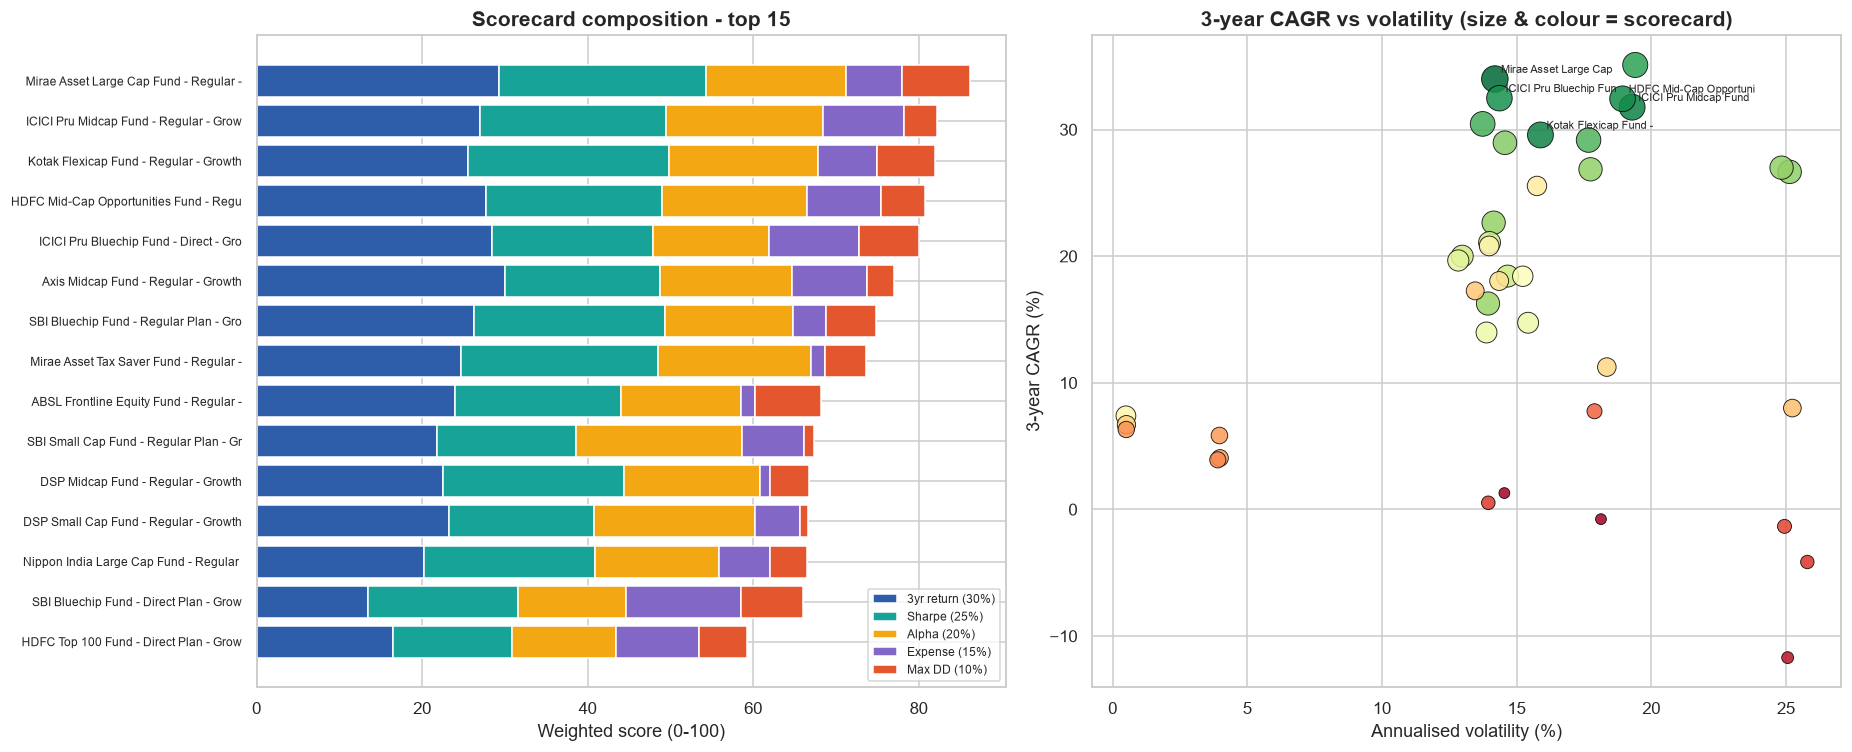

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

top15 = sc.head(15).iloc[::-1]
components = ["rank_return_3yr", "rank_sharpe", "rank_alpha", "rank_expense", "rank_drawdown"]
weights = [WEIGHTS["return_3yr"], WEIGHTS["sharpe"], WEIGHTS["alpha"],
           WEIGHTS["expense"], WEIGHTS["drawdown"]]
labels = ["3yr return (30%)", "Sharpe (25%)", "Alpha (20%)", "Expense (15%)", "Max DD (10%)"]
colours = ["#2E5EAA", "#17A398", "#F3A712", "#8367C7", "#E4572E"]

left = np.zeros(len(top15))
for comp, w, lab, colr in zip(components, weights, labels, colours):
    vals = top15[comp] * w
    axes[0].barh(top15["scheme_name"].str[:38], vals, left=left, label=lab, color=colr)
    left += vals
axes[0].set(title="Scorecard composition - top 15", xlabel="Weighted score (0-100)")
axes[0].tick_params(axis="y", labelsize=8)
axes[0].legend(fontsize=8, loc="lower right")

axes[1].scatter(sc["ann_vol_pct"], sc["cagr_3yr_pct"], s=sc["scorecard"] * 3.5,
                c=sc["scorecard"], cmap="RdYlGn", alpha=0.85, edgecolor="black", linewidth=0.6)
for _, r in sc.head(5).iterrows():
    axes[1].annotate(r["scheme_name"][:22], (r["ann_vol_pct"], r["cagr_3yr_pct"]),
                     fontsize=7.5, xytext=(4, 4), textcoords="offset points")
axes[1].set(title="3-year CAGR vs volatility (size & colour = scorecard)",
            xlabel="Annualised volatility (%)", ylabel="3-year CAGR (%)")

plt.tight_layout()
save_png(fig, "perf_05_scorecard")
plt.show()

## 8. Benchmark comparison and tracking error

  saved  reports/charts/perf_06_benchmark_comparison.png


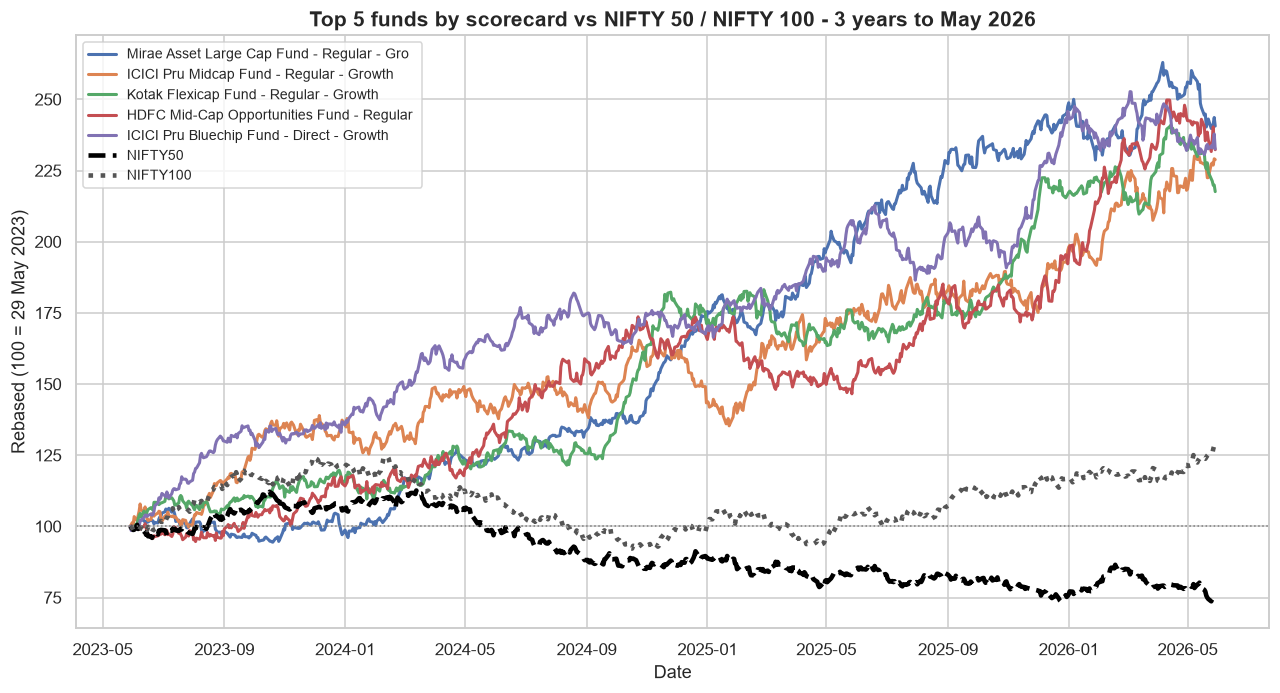

In [13]:
TOP_N = 5
top_funds = sc.head(TOP_N).index.tolist()
end = prices.index.max()
start_3y = end - pd.DateOffset(years=3)

indices = run_query("SELECT date_key, index_name, close_value FROM fact_benchmark "
                    "WHERE index_name IN ('NIFTY50','NIFTY100') ORDER BY date_key")
indices["date_key"] = pd.to_datetime(indices["date_key"])
idx_wide = indices.pivot(index="date_key", columns="index_name", values="close_value")

window_px = prices.loc[prices.index >= start_3y, top_funds]
window_idx = idx_wide.loc[idx_wide.index >= start_3y]


def rebase(d):
    return 100 * d / d.iloc[0]


fig, ax = plt.subplots(figsize=(14, 7))
for code in top_funds:
    ax.plot(window_px.index, rebase(window_px[code]), lw=2, label=names[code][:42])
for name, style in [("NIFTY50", "--"), ("NIFTY100", ":")]:
    ax.plot(window_idx.index, rebase(window_idx[name]), lw=3, ls=style,
            color="black" if name == "NIFTY50" else "#555555", label=name)
ax.axhline(100, color="grey", ls=":", lw=1)
ax.set(title=f"Top {TOP_N} funds by scorecard vs NIFTY 50 / NIFTY 100 - 3 years to {end:%b %Y}",
       xlabel="Date", ylabel=f"Rebased (100 = {window_px.index.min():%d %b %Y})")
ax.legend(fontsize=9, loc="upper left")
save_png(fig, "perf_06_benchmark_comparison")
plt.show()

In [14]:
# tracking error = std(fund return - benchmark return) * sqrt(252)
te_rows = []
for code in top_funds:
    fr = returns.loc[returns.index >= start_3y, code]
    for name in ("NIFTY50", "NIFTY100"):
        br = idx_wide[name].pct_change()
        j = pd.concat([fr, br], axis=1, join="inner").dropna()
        j.columns = ["fund", "bench"]
        diff = j["fund"] - j["bench"]
        te_rows.append({
            "scheme_name": names[code],
            "benchmark": name,
            "tracking_error_pct": diff.std() * np.sqrt(TRADING_DAYS) * 100,
            "fund_ann_return_pct": j["fund"].mean() * TRADING_DAYS * 100,
            "bench_ann_return_pct": j["bench"].mean() * TRADING_DAYS * 100,
            "correlation": j["fund"].corr(j["bench"]),
            "n_days": len(j),
        })

te = pd.DataFrame(te_rows)
te["excess_return_pp"] = (te["fund_ann_return_pct"] - te["bench_ann_return_pct"]).round(2)
print(te.round(3).to_string(index=False))

print(f"\nmean tracking error : {te.tracking_error_pct.mean():.2f}%")
print(f"mean correlation    : {te.correlation.mean():+.4f}")
print()
print("An actively managed large-cap fund normally shows 4-8% tracking error against its")
print("benchmark and correlation above 0.9. The near-zero correlation here inflates the")
print("tracking error mechanically: for uncorrelated series var(fund - bench) = var(fund)")
print("+ var(bench), so the figure measures the absence of a relationship rather than")
print("active risk taken against the index.")

                                       scheme_name benchmark  tracking_error_pct  fund_ann_return_pct  bench_ann_return_pct  correlation  n_days  excess_return_pp
     Mirae Asset Large Cap Fund - Regular - Growth   NIFTY50              19.182               29.101                -8.240       -0.020     785             37.34
     Mirae Asset Large Cap Fund - Regular - Growth  NIFTY100              18.787               29.101                 8.894        0.017     785             20.21
          ICICI Pru Midcap Fund - Regular - Growth   NIFTY50              22.831               28.497                -8.240        0.011     785             36.74
          ICICI Pru Midcap Fund - Regular - Growth  NIFTY100              23.251               28.497                 8.894       -0.032     785             19.60
            Kotak Flexicap Fund - Regular - Growth   NIFTY50              20.495               26.317                -8.240       -0.012     785             34.56
            Kotak Flex

## Summary

| Metric | Computed here | Reliable? |
|---|---|---|
| Daily returns | 46,000 observations, 40 schemes | Yes |
| CAGR 1yr / 3yr | from NAV | Yes |
| CAGR 5yr | not computable, history is 4.4 years | Vendor column only, not recomputed |
| Sharpe / Sortino | from daily returns, Rf = 6.5% | Yes, as an internally consistent ranking |
| Max drawdown | running-peak method | Yes, and it disagrees with the vendor column |
| Alpha / beta | OLS vs NIFTY 100 | No, R-squared is about 0 so there is nothing to recover |
| Tracking error | std of return difference | Inflated by the zero correlation |
| Scorecard | weighted percentile composite | Yes, as a relative ranking |

Files written: `reports/fund_scorecard.csv`, `reports/alpha_beta.csv`, and six PNG charts
under `reports/charts/perf_*.png`.

The scorecard, the Sharpe/Sortino ranks and the drawdowns are sound for comparing these
40 funds against each other. The market-relative metrics - alpha, beta and tracking error
- are reported as specified but should not be quoted as findings, for the reason given in
section 5.